# Week 7 Assignment: Fixed Effects & Panel Data
**CS 2700: Causal Inference** | Utah Valley University | Spring 2026

---

## Learning goals
- Explain why fixed effects uses **within-person** variation
- Distinguish **between** vs **within** variation
- Compare pooled OLS vs fixed-effects estimates in Python
- Run fixed effects in **R** using the `fixest` package
- Interpret R output and compare pooled OLS vs FE coefficients

## Workflow
1. **Parts 1-2 (Python):** Run code cells, inspect figures/tables, answer Questions 1.1 and 1.2
2. **Part 3 (R — Required):** Open **RStudio**, run the R code from Part 3, answer Question 3.1 based on your R output
3. Submit this notebook (`week07_experiments.ipynb`)

## Setup
This notebook uses:
- `pandas`, `numpy`
- `matplotlib`, `seaborn`
- `statsmodels` for pooled OLS and FE-with-indicators

If needed in Colab: `pip install statsmodels`

In [1]:
# Run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

pd.set_option('display.max_columns', 20)

print("Setup complete")

Setup complete


---

## Part 1: Simulate Panel Data — Does Exercise Reduce Colds?

> **Reading connection — Part 1 (The Problem):** The reading used this exact example: comparing different people's exercise and colds is biased because **genetics** (a time-invariant confounder) affects both. Now we simulate it with data.

### The Scenario (Same as the Reading)

**Research question:** Does exercise reduce the number of colds you get per year?

We simulate **50 people** observed over **6 years** (2019–2024). This is **panel data** — the same people tracked over time.

### What Each Column Means

| Column | What it represents | Example | Role |
|--------|-------------------|---------|------|
| `person` | Who (Person_01, Person_02, …) | Person_12 | The **unit** |
| `year` | Which year (2019–2024) | 2022 | The **time period** |
| `exercise` | Hours of exercise per week that year | 5.3 | The **treatment** (X) |
| `colds` | Number of colds that person got that year | 3 | The **outcome** (Y) |
| `genetics` | Immune system strength — strong genetics → more exercise AND fewer colds. **Same every year for the same person.** In real life you couldn't measure this — but since we're building the simulation, we include it so you can see how it works. **FE removes it without ever looking at it.** | 1.2 | **Unobserved, time-invariant confounder** |
| `flu_season` | How bad the flu was that year — bad flu year → everyone gets more colds. **Same for all people in a given year.** Again, we include it because we're building the data — in practice, time FE absorbs it automatically. | 0.3 | **Common time shock** (Reading Part 4) |

### The Confounding Problem

People with strong genetics tend to **both** exercise more **and** get fewer colds. So if we just compare people who exercise a lot to people who don't (pooled OLS), it looks like exercise helps more than it really does — because we're also picking up the genetics effect.

This is exactly comparing Alice to Bob in the reading.

### The Answer We're Looking For

We built the data so the **true causal effect = −0.5**. For every extra hour of exercise per week, a person gets **0.5 fewer colds per year**. The question is: which model recovers this number?

Run the next cell to create the data.

In [2]:
true_beta = -0.5
n_people = 50
years = np.arange(2019, 2025)

genetics = np.random.normal(0, 1, n_people)

rows = []
for i in range(n_people):
    for t, year in enumerate(years):
        flu_season = 0.3 * t + np.random.normal(0, 0.3)
        exercise = 4.0 + 1.5 * genetics[i] + 0.2 * t + np.random.normal(0, 1.0)
        colds = 5.0 + true_beta * exercise - 1.0 * genetics[i] + 0.4 * flu_season + np.random.normal(0, 0.8)
        rows.append({
            "person": f"Person_{i+1:02d}",
            "year": year,
            "exercise": round(exercise, 1),
            "colds": max(0, round(colds, 1)),
            "genetics": round(genetics[i], 2),
            "flu_season": round(flu_season, 2),
        })

df = pd.DataFrame(rows)

print("Data shape:", df.shape)
print("People:", df["person"].nunique())
print("Years:", df["year"].min(), "to", df["year"].max())
print()
print(df.head(12))
print()
print("NOTE: 'genetics' and 'flu_season' are visible here because WE built the data.")
print("In real research you would NOT have these columns — that's the whole point of FE.")
print("FE removes them without ever seeing them.")

Data shape: (300, 6)
People: 50
Years: 2019 to 2024

       person  year  exercise  colds  genetics  flu_season
0   Person_01  2019       4.4    1.8      0.50        0.10
1   Person_01  2020       6.0    2.5      0.50        0.48
2   Person_01  2021       4.8    2.5      0.50        0.35
3   Person_01  2022       4.9    2.4      0.50        1.19
4   Person_01  2023       4.3    3.3      0.50        0.87
5   Person_01  2024       5.7    3.2      0.50        1.91
6   Person_02  2019       3.1    3.9     -0.14        0.11
7   Person_02  2020       4.0    4.7     -0.14        0.76
8   Person_02  2021       5.0    2.6     -0.14       -0.19
9   Person_02  2022       4.5    1.6     -0.14        0.81
10  Person_02  2023       4.9    4.3     -0.14        1.13
11  Person_02  2024       4.0    3.3     -0.14        1.34

NOTE: 'genetics' and 'flu_season' are visible here because WE built the data.
In real research you would NOT have these columns — that's the whole point of FE.
FE removes them wit

---

### Figure 1: Two Different Questions About the Same Data

> **Reading connection — Part 2 (Between vs. Within).**

These two plots ask **different questions** about the same data. That's the whole point.

#### Left plot — "Do people who exercise more get fewer colds?"

This compares **different people** to each other. Each dot is one person's average over all years.

- Person_01 averages 5 hrs/wk of exercise and 2.5 colds/year → one dot
- Person_02 averages 3 hrs/wk and 4 colds/year → another dot
- The line shows the trend across all 50 people

**Answer:** Yes, people who exercise more get fewer colds. But **we can't trust this** — people who exercise more might just have better genetics. The slope mixes the exercise effect with the genetics effect.

#### Right plot — "When the SAME person exercises more than usual, do they get fewer colds than usual?"

This compares **each person to themselves**. We subtract each person's own average, so the dots show *deviations from normal*:

- If Person_01 usually exercises 5 hrs/wk but this year did 6 → their dot is at +1 on the x-axis
- If they usually get 2.5 colds but this year got 2 → their dot is at −0.5 on the y-axis
- That dot means: "the year Person_01 exercised more than usual, they also got fewer colds than usual"

**Answer:** Yes — and this time we **can trust it**. Person_01's genetics didn't change between years, so genetics can't explain the year-to-year changes. The slope here is the **FE estimate**, and it's closer to the true effect of −0.5.

#### Why the slopes differ

| | Left plot | Right plot |
|---|---|---|
| **Question** | Do exercisers get fewer colds? | When YOU exercise more, do YOU get fewer colds? |
| **Compares** | Different people to each other | Each person to themselves |
| **Genetics** | Mixed in (biases the slope) | Removed (same person, same genetics) |
| **Slope** | Too negative (~−0.85) | Close to true effect (~−0.5) |

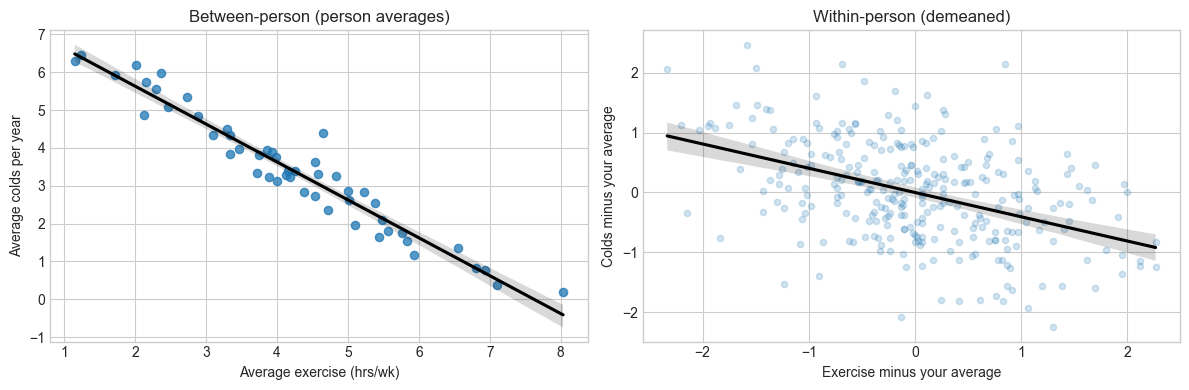

In [3]:
means = df.groupby("person")[["exercise", "colds"]].transform("mean")
df["exercise_within"] = df["exercise"] - means["exercise"]
df["colds_within"] = df["colds"] - means["colds"]

between_df = df.groupby("person", as_index=False)[["exercise", "colds"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.regplot(data=between_df, x="exercise", y="colds",
            scatter_kws={"alpha": 0.75, "s": 35}, line_kws={"color": "black"}, ax=axes[0])
axes[0].set_title("Between-person (person averages)")
axes[0].set_xlabel("Average exercise (hrs/wk)")
axes[0].set_ylabel("Average colds per year")

sns.regplot(data=df, x="exercise_within", y="colds_within",
            scatter_kws={"alpha": 0.2, "s": 20}, line_kws={"color": "black"}, ax=axes[1])
axes[1].set_title("Within-person (demeaned)")
axes[1].set_xlabel("Exercise minus your average")
axes[1].set_ylabel("Colds minus your average")

plt.tight_layout()
plt.show()

#### What You Should See in Figure 1

**Look at the two slopes.** They should be different. Here's why:

- **Left slope** (between-person) is **steeply negative** — maybe around −0.8 or −0.9. It says "for every extra hour of exercise, people get almost 1 fewer cold." That sounds too good to be true — and it is. The slope is exaggerated because it also captures genetics: people with strong genetics both exercise more AND get fewer colds. The slope picks up both effects mixed together.

- **Right slope** (within-person) is **less negative** — closer to −0.5 (the true effect). It says "when the same person exercises one hour more than their usual, they get about 0.5 fewer colds than their usual." This is more trustworthy because genetics is the same for that person in every year — it cancels out.

**Yes, they SHOULD be different.** That difference is the whole point of fixed effects. The gap between the two slopes is caused by the time-invariant confounder (genetics). FE removes it; pooled OLS doesn't.

**If the slopes were the same**, it would mean there's no confounding from time-invariant traits — and you wouldn't need FE at all.

---

### Figure 2: Individual Trajectories Over Time

> **Reading connection — Part 2 (Between vs. Within).**

This plot shows colds per year for 6 randomly selected people. Each colored line = one person.

**How to read it:**
- **Vertical gaps between lines** = **between** variation. Some people are consistently higher (more colds every year, probably weaker genetics). Some are consistently lower. FE **removes** these gaps.
- **Year-to-year wiggles within each line** = **within** variation. One year a person gets more colds, the next year fewer. This is what changes when exercise changes. FE **uses only** these wiggles.

**Key insight:** If you only look at how each person's line wiggles up and down (ignoring how high or low the line is), you're doing fixed effects.

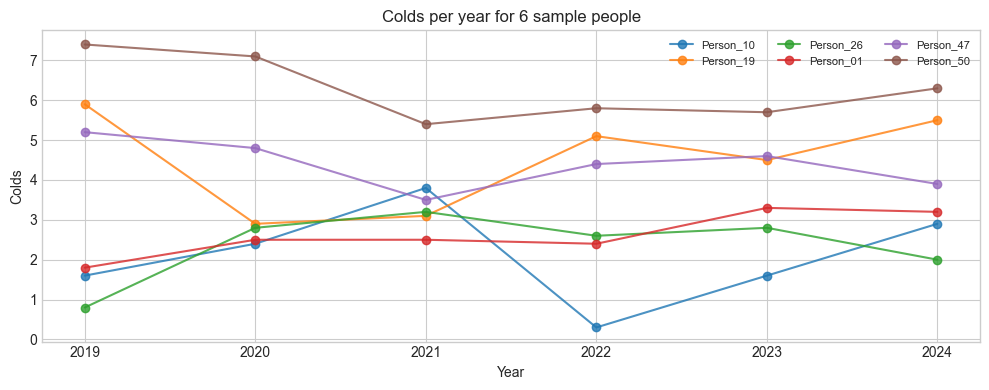

In [4]:
sample = np.random.choice(df["person"].unique(), size=6, replace=False)
fig, ax = plt.subplots(figsize=(10, 4))
for p in sample:
    d = df[df["person"] == p].sort_values("year")
    ax.plot(d["year"], d["colds"], marker="o", linewidth=1.5, alpha=0.8, label=p)
ax.set_title("Colds per year for 6 sample people")
ax.set_xlabel("Year")
ax.set_ylabel("Colds")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

---

## Part 2: Which Model Recovers the True Effect?

> **Reading connection — Part 3 (The Equation):** The reading described two ways to implement FE: (1) subtract each person's average, (2) add person indicator columns. Both give the same coefficient. Here we run both and verify they match.

We estimate the effect of exercise on colds using three models:

| Model | What it does | Expected result |
|-------|-------------|------------------|
| **Pooled OLS** | Compares all people to each other, ignoring that some have better genetics | **Biased** — genetics confounds the comparison |
| **FE (person + year indicators)** | Adds a yes/no column for each person and each year, so each person gets their own baseline | **Close to −0.5** — genetics removed |
| **FE (demeaned)** | Subtracts each person's average and each year's average, then runs OLS on the leftovers | **Same as above** — mathematically equivalent |

The true effect is **−0.5** (we built it that way). Let's see which model gets closest.

In [5]:
pooled = smf.ols("colds ~ exercise", data=df).fit()
fe_indicators = smf.ols("colds ~ exercise + C(person) + C(year)", data=df).fit()

resid_y = smf.ols("colds ~ C(person) + C(year)", data=df).fit().resid
resid_x = smf.ols("exercise ~ C(person) + C(year)", data=df).fit().resid
resid_df = pd.DataFrame({"resid_y": resid_y, "resid_x": resid_x})
fe_demeaned = smf.ols("resid_y ~ resid_x - 1", data=resid_df).fit()

results = pd.DataFrame({
    "Model": [
        "True effect",
        "Pooled OLS (no FE)",
        "FE (person + year indicators)",
        "FE (demeaned/residualized)",
    ],
    "Exercise Coefficient": [
        true_beta,
        pooled.params["exercise"],
        fe_indicators.params["exercise"],
        fe_demeaned.params["resid_x"],
    ],
})

print("Coefficient comparison:")
print(results.round(3))

Coefficient comparison:
                           Model  Exercise Coefficient
0                    True effect                -0.500
1             Pooled OLS (no FE)                -0.848
2  FE (person + year indicators)                -0.490
3     FE (demeaned/residualized)                -0.490


---

### Stress Test: What If You Also Changed Your Diet?

> **Reading connection — Part 5 (When FE Fails):** The reading warned that FE cannot remove **time-varying confounders**. It used this exact example: you started exercising more AND eating healthier the same year. Now we simulate it.

FE removes genetics (time-invariant). But what if someone **also changed their diet** the same year they started exercising more?

We add a `diet_change` variable that:
- Affects **both** exercise and colds (people who improve their diet also tend to exercise more, and better diet independently reduces colds)
- **Changes from year to year** for the same person (it's time-varying)

Since `diet_change` varies over time, FE **cannot** remove it. The exercise estimate will be biased — unless we explicitly control for `diet_change`.

In [6]:
df["diet_change"] = np.random.normal(0, 1, len(df))
df["exercise_tv"] = df["exercise"] + 0.8 * df["diet_change"]
df["colds_tv"] = (
    5.0 + true_beta * df["exercise_tv"]
    - 1.0 * df["genetics"]
    + 0.4 * df["flu_season"]
    - 0.6 * df["diet_change"]
    + np.random.normal(0, 0.8, len(df))
)

fe_no_diet = smf.ols("colds_tv ~ exercise_tv + C(person) + C(year)", data=df).fit()
fe_with_diet = smf.ols("colds_tv ~ exercise_tv + diet_change + C(person) + C(year)", data=df).fit()

stress = pd.DataFrame({
    "Model": ["True effect", "FE (omits diet change)", "FE (+ controls for diet)"],
    "Exercise Coefficient": [true_beta, fe_no_diet.params["exercise_tv"], fe_with_diet.params["exercise_tv"]],
})

print("Time-varying confounder stress test:")
print(stress.round(3))

Time-varying confounder stress test:
                      Model  Exercise Coefficient
0               True effect                -0.500
1    FE (omits diet change)                -0.857
2  FE (+ controls for diet)                -0.481


---

### Summary Chart: All Models Side by Side

This bar chart shows every model's estimate next to the true effect (dashed line at −0.5).

Since the true effect is **negative** (exercise *reduces* colds), a more negative bar means the model **exaggerates** the benefit. A bar closer to −0.5 is better.

- **Pooled OLS** is too negative (e.g., ~−0.85) — it exaggerates the exercise effect because genetics confounds the comparison
- **FE (indicators or demeaned)** is close to −0.5 — genetics (time-invariant) has been removed
- **FE without diet control** is too negative again — diet change (time-varying confounder) affects both exercise and colds, biasing the estimate
- **FE with diet control** is back near −0.5 — the time-varying confounder is now explicitly controlled

### Important: Whose Effect Does FE Estimate?

The FE coefficient is **not** a simple average of everyone's effect. It's a **weighted average**, where people whose exercise changed the most over time count more.

**Why?** FE uses only within-person variation. If Alice's exercise swings from 2 hrs to 8 hrs across years, she contributes a lot of within variation. If Bob exercises ~5 hrs every single year, he has almost no within variation — FE has nothing to learn from him.

**What this means:**
- The FE estimate is closer to the effect **for people whose treatment actually changed**
- If the true effect differs across people (e.g., exercise helps some people more than others), the FE estimate reflects the people with the most variation — not an equal average of everyone
- This is fine for most purposes, but worth knowing: FE tells you the effect for the type of person whose behavior actually changed

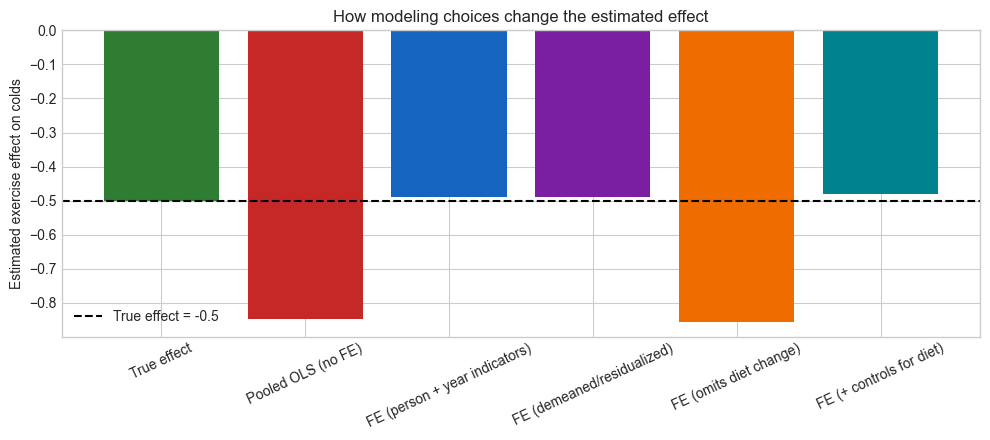

In [7]:
plot_df = pd.concat([
    results[["Model", "Exercise Coefficient"]].rename(columns={"Exercise Coefficient": "Coefficient"}),
    stress.iloc[1:][["Model", "Exercise Coefficient"]].rename(columns={"Exercise Coefficient": "Coefficient"}),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#2e7d32", "#c62828", "#1565c0", "#7b1fa2", "#ef6c00", "#00838f"]
ax.bar(plot_df["Model"], plot_df["Coefficient"], color=colors[:len(plot_df)])
ax.axhline(true_beta, color="black", linestyle="--", linewidth=1.5, label=f"True effect = {true_beta}")
ax.set_ylabel("Estimated exercise effect on colds")
ax.set_title("How modeling choices change the estimated effect")
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()

---

### Question 1.1

Use the figures and tables from Parts 1-2 to answer:

**a)** In your own words, what is the core idea of unit fixed effects? (1-2 sentences)

**b)** Look at **Figure 1** (between vs. within scatter plots). Why do the two plots have different slopes? What does each slope represent?

**c)** Look at the **Coefficient Comparison table** (Part 2). Pooled OLS gives a more negative coefficient than FE. Why does pooled OLS exaggerate the exercise effect, while FE gets closer to −0.5?

**d)** Look at the **Stress Test table**. Why is the FE estimate biased when diet change is omitted? Why does adding `diet_change` as a control fix it?

**e)** Read the **"Whose Effect Does FE Estimate?"** section above the chart. If Person A's exercise changes a lot from year to year and Person B's stays roughly the same, whose experience does the FE coefficient reflect more? Why?

---

*Double-click to answer:*

**Your Answer:**

a) A unit fixed effect is used to control all varaibles that are unchanging between variables. An example is how much someone gets paid with time, it would control for any outside effect that can change one's pay.

b) They have different slopes because the slope on the left compares people with others over time whereas the slope on the right compares a person with themselves.  \                                                                                                                                      
c) The pooled is more negative because it leaves out the biased genetic variable. FE gets closer to -0.5 because it compares each person with themselves.

d) 

e) 

---

---

### Question 1.2

**a)** Give one realistic panel-data example (not exercise/colds) where FE would be appropriate. Name the unit, time period, treatment, outcome, and at least one time-invariant confounder that FE would remove.

**b)** In your example, name one **time-varying confounder** that could still bias your FE estimate. Explain why FE can't remove it.

**c)** Look at the **Coefficient Comparison table** (Part 2). The "FE (person + year indicators)" and "FE (demeaned/residualized)" rows have the same coefficient. Why? Briefly describe what each method does.

---

*Double-click to answer:*

**Your Answer:**

a) 

b) 

c) 

---

---

## Part 3: Fixed Effects in R (Required)

> **Reading connection — Part 4 (Time FE / Two-Way FE):** The reading explained that unit FE removes stable traits (genetics), and adding **time FE** also removes common shocks (flu seasons). Here you run all three models in R and compare.

### What this R script does

Same exercise/colds scenario as the Python simulation (30 people × 6 years). The data has:
- **Genetics** (unobserved, time-invariant) — makes pooled OLS too negative
- **A time trend** — both exercise and colds trend upward over the years (people exercise more as they age, and flu seasons get worse). This trend confounds person-only FE because it creates a positive bias that partially offsets the genetics bias.

### What results to expect

| Model | What it controls for | Expected coefficient | Why |
|-------|---------------------|---------------------|-----|
| Pooled OLS | Nothing | **More negative** than −0.5 | Genetics bias (strong genetics → more exercise AND fewer colds) makes effect look bigger |
| Person FE only | Genetics (time-invariant) | **Less negative** than −0.5 | Genetics removed, but year trends not removed — exercise and colds both trend up, creating a positive bias |
| Two-way FE | Genetics AND year trends | **Close to −0.5** | Both confounders removed |

Open **RStudio** and run the R code below.

**Install once** (if you haven't already):

```r
install.packages("fixest")
```

**Then run this script:**

```r
# ---- Step 1: Load packages ----
library(fixest)

# ---- Step 2: Create exercise/colds panel data ----
set.seed(42)
n_people <- 30
n_years  <- 6

person   <- rep(paste0("Person_", sprintf("%02d", 1:n_people)), each = n_years)
year     <- rep(2019:(2019 + n_years - 1), times = n_people)

# Genetics: time-invariant, unobserved confounder
genetics <- rep(rnorm(n_people, 0, 1), each = n_years)

# Exercise: affected by genetics (strong genetics -> more exercise)
exercise <- 4.0 + 1.5 * genetics + 0.2 * (year - 2019) + rnorm(n_people * n_years, 0, 1)

# Colds: true effect of exercise = -0.5
true_effect <- -0.5
colds <- 5.0 + true_effect * exercise - 1.0 * genetics + 0.3 * (year - 2019) + rnorm(n_people * n_years, 0, 0.8)
colds <- pmax(colds, 0)

df <- data.frame(person, year, exercise, colds)

cat("Data shape:", nrow(df), "rows x", ncol(df), "columns\n")
cat("People:", length(unique(df$person)), "\n")
cat("Years:", min(df$year), "to", max(df$year), "\n\n")
head(df)

# ---- Step 3: Pooled OLS (no fixed effects) ----
m_pooled <- lm(colds ~ exercise, data = df)
cat("\n--- Pooled OLS (no FE) ---\n")
cat("Exercise coefficient:", round(coef(m_pooled)["exercise"], 3), "\n")

# ---- Step 4: Person FE only ----
m_person_fe <- feols(colds ~ exercise | person, data = df)
cat("\n--- Person FE only ---\n")
cat("Exercise coefficient:", round(coef(m_person_fe)["exercise"], 3), "\n")

# ---- Step 5: Two-way FE (person + year) ----
m_twfe <- feols(colds ~ exercise | person + year, data = df)
cat("\n--- Two-way FE (person + year) ---\n")
cat("Exercise coefficient:", round(coef(m_twfe)["exercise"], 3), "\n")

# ---- Step 6: Compare all three ----
cat("\n--- Coefficient Comparison ---\n")
cat("True effect:          ", true_effect, "\n")
cat("Pooled OLS:           ", round(coef(m_pooled)["exercise"], 3), "\n")
cat("Person FE only:       ", round(coef(m_person_fe)["exercise"], 3), "\n")
cat("Two-way FE (person+yr):", round(coef(m_twfe)["exercise"], 3), "\n")

# ---- Step 7: Full summary of two-way FE ----
cat("\n--- Full Two-Way FE Summary ---\n")
summary(m_twfe)
```

---

### Question 3.1 (Based on your R output)

Run all the R code above in RStudio, then answer these questions.

**a)** What is the pooled OLS coefficient on exercise? Is it more negative or less negative than −0.5? Explain why pooled OLS exaggerates the exercise effect (hint: genetics confounds the between-person comparison).

**b)** What is the person-only FE coefficient? It should be less negative than pooled OLS. But is it close to −0.5? If not, explain what confounder person FE did NOT remove (hint: both exercise and colds trend upward over the years).

**c)** What is the two-way FE (person + year) coefficient? Is it closer to −0.5 than person-only FE? Explain what adding year FE removed that person FE alone couldn't.

**d)** Look at the full `summary(m_twfe)` output. What is the standard error? A small standard error relative to the coefficient means the estimate is precise (we can be confident it's near −0.5, not just luck).

---

*Double-click to answer (paste your R output here too):*

**Your Answer:**

a)

b)

c)

d)

---

## Submission checklist

- [ ] Ran all Python code cells (Parts 1-2)
- [ ] Answered Questions 1.1 and 1.2
- [ ] Ran the R script in RStudio (Part 3)
- [ ] Pasted R output and answered Question 3.1
- [ ] Saved and submitted `week07_experiments.ipynb`

**Next week** builds directly on this FE intuition.